In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Find the dataset file in your Google Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'lending' in file.lower() or 'accepted' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Capstone Project/accepted_2007_to_2018Q4.csv


In [3]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/Capstone Project/accepted_2007_to_2018Q4.csv'
df = pd.read_csv(file_path, low_memory=False)

# Show basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2260701, 151)

First 5 rows:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check the target variable - loan_status
print("Loan Status Values:")
print(df['loan_status'].value_counts())

Loan Status Values:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [5]:
# Keep only Fully Paid and Charged Off loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Create binary target variable: 1 = Default, 0 = Fully Paid
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Sample 200,000 rows for manageable computation
df = df.sample(n=200000, random_state=42)

# Check the result
print("Dataset shape after filtering:", df.shape)
print("\nTarget variable distribution:")
print(df['target'].value_counts())
print("\nDefault rate:", round(df['target'].mean() * 100, 2), "%")

Dataset shape after filtering: (200000, 152)

Target variable distribution:
target
0    160274
1     39726
Name: count, dtype: int64

Default rate: 19.86 %


In [6]:
# Select the most relevant columns for prediction
cols = [
    'loan_amnt',        # Loan amount requested
    'int_rate',         # Interest rate
    'installment',      # Monthly payment
    'grade',            # Lending Club assigned grade
    'sub_grade',        # More detailed grade
    'emp_length',       # Employment length
    'home_ownership',   # Renter, owner, mortgage
    'annual_inc',       # Annual income
    'verification_status', # Income verified?
    'purpose',          # Purpose of loan
    'dti',              # Debt-to-income ratio
    'delinq_2yrs',      # Delinquencies in past 2 years
    'open_acc',         # Number of open credit lines
    'pub_rec',          # Public records (bankruptcies)
    'revol_bal',        # Revolving balance
    'revol_util',       # Revolving line utilization
    'total_acc',        # Total credit lines
    'target'            # Our target variable
]

df = df[cols]

print("Shape after column selection:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape after column selection: (200000, 18)

Missing values per column:
loan_amnt                  0
int_rate                   0
installment                0
grade                      0
sub_grade                  0
emp_length             11762
home_ownership             0
annual_inc                 0
verification_status        0
purpose                    0
dti                       52
delinq_2yrs                0
open_acc                   0
pub_rec                    0
revol_bal                  0
revol_util               133
total_acc                  0
target                     0
dtype: int64


In [7]:
# Fill missing employment length with 'Unknown'
df['emp_length'] = df['emp_length'].fillna('Unknown')

# Fill missing numerical columns with median
df['dti'] = df['dti'].fillna(df['dti'].median())
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# Confirm no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nAll missing values handled! ✅")

Missing values after cleaning:
loan_amnt              0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
target                 0
dtype: int64

All missing values handled! ✅


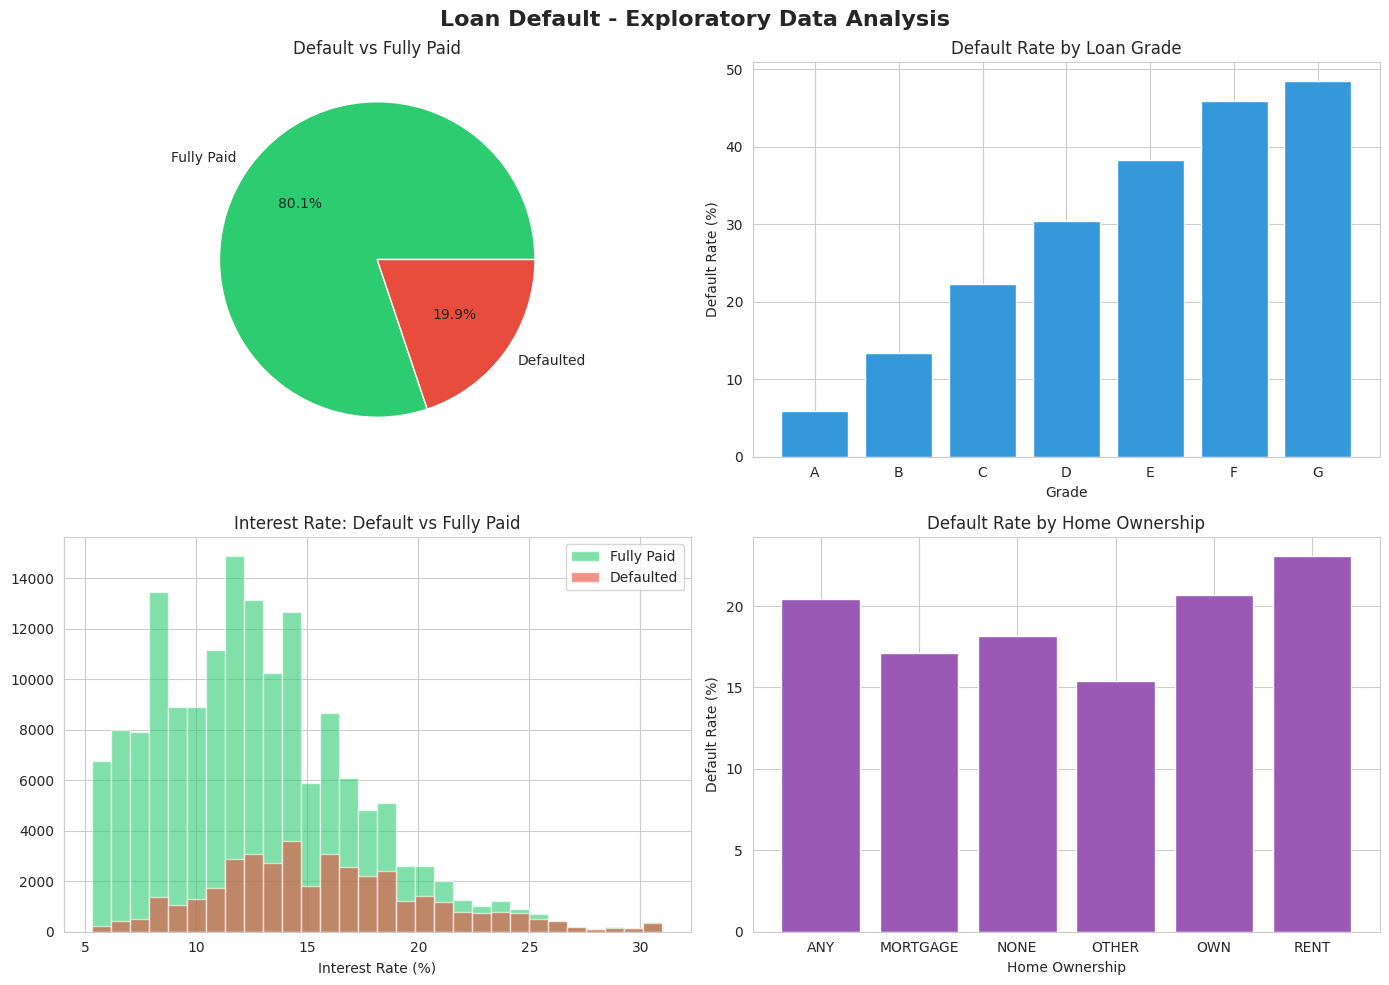

EDA charts saved! ✅


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loan Default - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Chart 1: Default vs Fully Paid
axes[0,0].pie(df['target'].value_counts(),
              labels=['Fully Paid', 'Defaulted'],
              autopct='%1.1f%%',
              colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Default vs Fully Paid')

# Chart 2: Default rate by Grade
grade_default = df.groupby('grade')['target'].mean() * 100
axes[0,1].bar(grade_default.index, grade_default.values, color='#3498db')
axes[0,1].set_title('Default Rate by Loan Grade')
axes[0,1].set_xlabel('Grade')
axes[0,1].set_ylabel('Default Rate (%)')

# Chart 3: Interest Rate Distribution
axes[1,0].hist(df[df['target']==0]['int_rate'], bins=30, alpha=0.6,
               color='#2ecc71', label='Fully Paid')
axes[1,0].hist(df[df['target']==1]['int_rate'], bins=30, alpha=0.6,
               color='#e74c3c', label='Defaulted')
axes[1,0].set_title('Interest Rate: Default vs Fully Paid')
axes[1,0].set_xlabel('Interest Rate (%)')
axes[1,0].legend()

# Chart 4: Default rate by Home Ownership
home_default = df.groupby('home_ownership')['target'].mean() * 100
axes[1,1].bar(home_default.index, home_default.values, color='#9b59b6')
axes[1,1].set_title('Default Rate by Home Ownership')
axes[1,1].set_xlabel('Home Ownership')
axes[1,1].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved! ✅")

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode categorical columns
cat_cols = ['grade', 'sub_grade', 'emp_length',
            'home_ownership', 'verification_status', 'purpose']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nData preparation complete! ✅")

Training set size: (160000, 17)
Test set size: (40000, 17)

Data preparation complete! ✅


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time

# Train Logistic Regression
print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_time = time.time() - start

# Evaluate
lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])

print(f"\n✅ Logistic Regression trained in {lr_time:.1f} seconds")
print(f"ROC-AUC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Fully Paid', 'Defaulted']))

Training Logistic Regression...

✅ Logistic Regression trained in 1.6 seconds
ROC-AUC Score: 0.7052

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.66      0.76     32055
   Defaulted       0.32      0.64      0.42      7945

    accuracy                           0.66     40000
   macro avg       0.60      0.65      0.59     40000
weighted avg       0.77      0.66      0.69     40000



In [11]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
print("Training Decision Tree...")
start = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42)
dt_model.fit(X_train, y_train)

dt_time = time.time() - start

# Evaluate
dt_pred = dt_model.predict(X_test)
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])

print(f"\n✅ Decision Tree trained in {dt_time:.1f} seconds")
print(f"ROC-AUC Score: {dt_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['Fully Paid', 'Defaulted']))

Training Decision Tree...

✅ Decision Tree trained in 2.1 seconds
ROC-AUC Score: 0.6831

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.60      0.72     32055
   Defaulted       0.30      0.68      0.41      7945

    accuracy                           0.62     40000
   macro avg       0.59      0.64      0.56     40000
weighted avg       0.77      0.62      0.66     40000



In [12]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
print("Training Random Forest (this may take a few minutes)...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)  # Uses all CPU cores to speed up
rf_model.fit(X_train, y_train)

rf_time = time.time() - start

# Evaluate
rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print(f"\n✅ Random Forest trained in {rf_time:.1f} seconds")
print(f"ROC-AUC Score: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Fully Paid', 'Defaulted']))

Training Random Forest (this may take a few minutes)...

✅ Random Forest trained in 33.3 seconds
ROC-AUC Score: 0.7069

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.88      0.65      0.75     32055
   Defaulted       0.31      0.66      0.43      7945

    accuracy                           0.65     40000
   macro avg       0.60      0.65      0.59     40000
weighted avg       0.77      0.65      0.68     40000



In [13]:
from xgboost import XGBClassifier

# Train XGBoost
print("Training XGBoost (this may take a few minutes)...")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=4,  # Handles class imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0)
xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start

# Evaluate
xgb_pred = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print(f"\n✅ XGBoost trained in {xgb_time:.1f} seconds")
print(f"ROC-AUC Score: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Fully Paid', 'Defaulted']))

Training XGBoost (this may take a few minutes)...

✅ XGBoost trained in 2.2 seconds
ROC-AUC Score: 0.7146

Classification Report:
              precision    recall  f1-score   support

  Fully Paid       0.89      0.65      0.75     32055
   Defaulted       0.32      0.67      0.43      7945

    accuracy                           0.65     40000
   macro avg       0.60      0.66      0.59     40000
weighted avg       0.77      0.65      0.69     40000



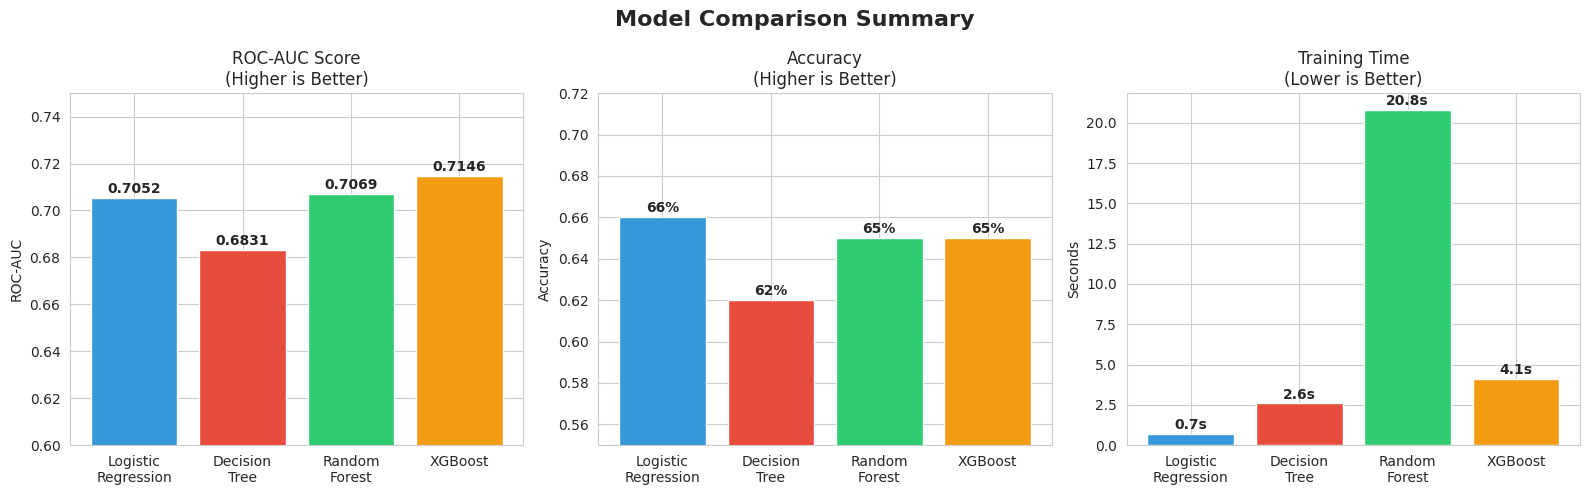

Model comparison chart saved! ✅


In [14]:
# Model Comparison Visualization
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
auc_scores = [0.7052, 0.6831, 0.7069, 0.7146]
accuracies = [0.66, 0.62, 0.65, 0.65]
train_times = [0.7, 2.6, 20.8, 4.1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison Summary', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Chart 1: ROC-AUC Scores
bars1 = axes[0].bar(models, auc_scores, color=colors)
axes[0].set_title('ROC-AUC Score\n(Higher is Better)')
axes[0].set_ylim(0.6, 0.75)
axes[0].set_ylabel('ROC-AUC')
for bar, score in zip(bars1, auc_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Accuracy
bars2 = axes[1].bar(models, accuracies, color=colors)
axes[1].set_title('Accuracy\n(Higher is Better)')
axes[1].set_ylim(0.55, 0.72)
axes[1].set_ylabel('Accuracy')
for bar, acc in zip(bars2, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{acc:.0%}', ha='center', va='bottom', fontweight='bold')

# Chart 3: Training Time
bars3 = axes[2].bar(models, train_times, color=colors)
axes[2].set_title('Training Time\n(Lower is Better)')
axes[2].set_ylabel('Seconds')
for bar, t in zip(bars3, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{t}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved! ✅")

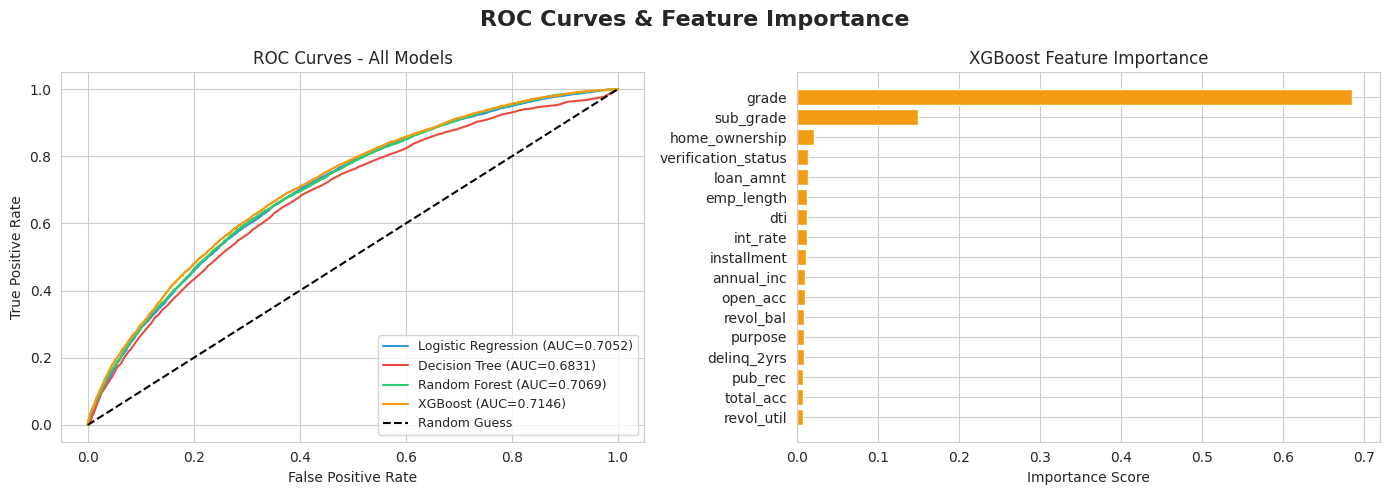

ROC curves and feature importance saved! ✅


In [15]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curves & Feature Importance', fontsize=16, fontweight='bold')

# Chart 1: ROC Curves for all models
models_info = [
    ('Logistic Regression', lr_model, '#3498db'),
    ('Decision Tree', dt_model, '#e74c3c'),
    ('Random Forest', rf_model, '#2ecc71'),
    ('XGBoost', xgb_model, '#f39c12')
]

for name, model, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curves - All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Chart 2: XGBoost Feature Importance
import pandas as pd
feature_names = ['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade',
                 'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
                 'purpose', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec',
                 'revol_bal', 'revol_util', 'total_acc']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importance_df['feature'], importance_df['importance'], color='#f39c12')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('roc_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves and feature importance saved! ✅")

In [16]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("Starting hyperparameter tuning on XGBoost...")
print("This may take 5-10 minutes...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [3, 4, 5]
}

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
print(random_search.best_params_)
print(f"\nBest Cross-Validation ROC-AUC: {random_search.best_score_:.4f}")

# Evaluate on test set
best_xgb = random_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])

print(f"Test ROC-AUC (Tuned XGBoost): {best_xgb_auc:.4f}")
print(f"Previous ROC-AUC (Default XGBoost): 0.7146")
print(f"Improvement: {(best_xgb_auc - 0.7146):.4f}")

Starting hyperparameter tuning on XGBoost...
This may take 5-10 minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best parameters found:
{'subsample': 0.8, 'scale_pos_weight': 3, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best Cross-Validation ROC-AUC: 0.7132
Test ROC-AUC (Tuned XGBoost): 0.7158
Previous ROC-AUC (Default XGBoost): 0.7146
Improvement: 0.0012


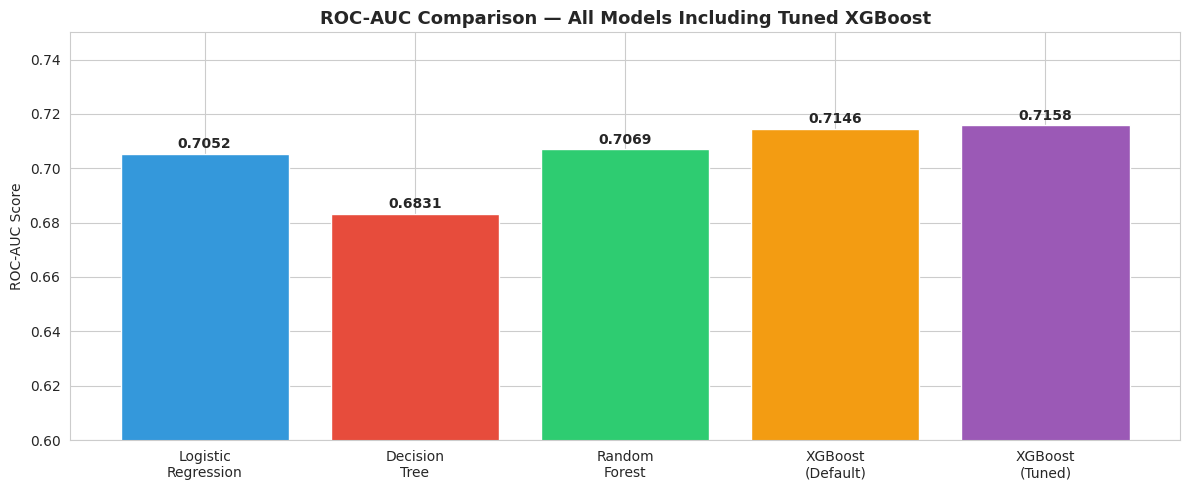

Final comparison chart saved! ✅


In [17]:
# Updated model comparison with tuned XGBoost
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest',
          'XGBoost\n(Default)', 'XGBoost\n(Tuned)']
auc_scores = [0.7052, 0.6831, 0.7069, 0.7146, 0.7158]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(models, auc_scores, color=colors)
ax.set_title('ROC-AUC Comparison — All Models Including Tuned XGBoost',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.60, 0.75)
ax.set_ylabel('ROC-AUC Score')

for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison chart saved! ✅")

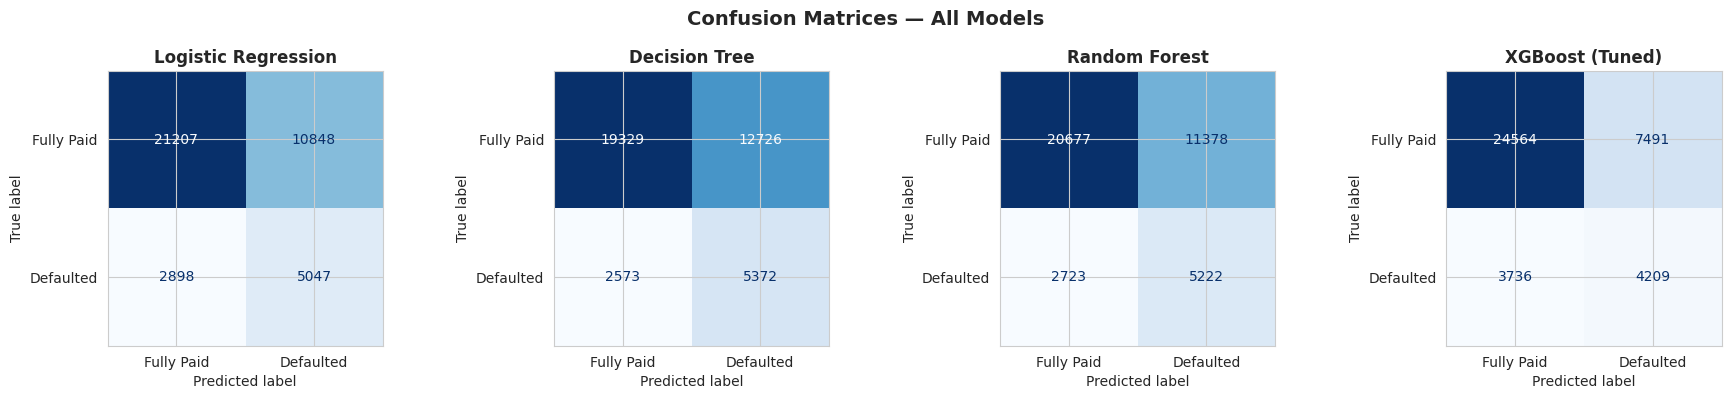

Confusion matrices saved! ✅


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

models_info = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred),
    ('XGBoost (Tuned)', best_xgb_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fully Paid', 'Defaulted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved! ✅")